To build a machine learning model to classify whether a particular tweet is hatespeech or not

In [ ]:
# import the required libraries
# importing pandas and numpy library for basic data operations
import pandas as pd
import numpy as np
import re
# import seaborn and matplotlib to visualize data
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
import nltk
nltk.download('stopwords')
style.use('ggplot')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
# for removing stopwords
from nltk.corpus import stopwords
# set language for stopwords
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
# import text document TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# import evaluation matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Load the data
# https://www.kaggle.com/datasets/arkhoshghalb/twitter-sentiment-analysis-hatred-speech?select=train.csv
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io
tweet_df = pd.read_csv(io.BytesIO(uploaded['train.csv']))
print(tweet_df)

Saving train.csv to train.csv
          id  label                                              tweet
0          1      0   @user when a father is dysfunctional and is s...
1          2      0  @user @user thanks for #lyft credit i can't us...
2          3      0                                bihday your majesty
3          4      0  #model   i love u take with u all the time in ...
4          5      0             factsguide: society now    #motivation
...      ...    ...                                                ...
31957  31958      0  ate @user isz that youuu?ðððððð...
31958  31959      0    to see nina turner on the airwaves trying to...
31959  31960      0  listening to sad songs on a monday morning otw...
31960  31961      1  @user #sikh #temple vandalised in in #calgary,...
31961  31962      0                   thank you @user for you follow  

[31962 rows x 3 columns]


In [ ]:
# Preview the data
tweet_df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
# information about data , how many field, column name etc...
tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [ ]:
# analyze data
# printing random tweets
print(tweet_df['tweet'].iloc[0],"\n")
print(tweet_df['tweet'].iloc[1],"\n")
print(tweet_df['tweet'].iloc[2],"\n")
print(tweet_df['tweet'].iloc[3],"\n")
print(tweet_df['tweet'].iloc[4],"\n")

 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run 

@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked 

  bihday your majesty 

#model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦   

 factsguide: society now    #motivation 



In [ ]:
#  Data Preprocessing - convert uppercase to lower case,remove hastag and url using re.sub(),
# remove the punctuations, remove all stopwords

#creating a function to process the data
def data_processing(tweet):
    tweet = tweet.lower()
    tweet = re.sub(r"https\S+|www\S+http\S+", '', tweet, flags = re.MULTILINE)
    tweet = re.sub(r'\@w+|\#','', tweet)
    tweet = re.sub(r'[^\w\s]','',tweet)
    tweet = re.sub(r'ð','',tweet)
    tweet_tokens = word_tokenize(tweet)
    filtered_tweets = [w for w in tweet_tokens if not w in stop_words]
    return " ".join(filtered_tweets)

In [ ]:
# apply preprocessing function on data
import nltk
nltk.download('punkt')
tweet_df.tweet = tweet_df['tweet'].apply(data_processing)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# lemmatization - WordNetLemmatizer()
lemmatizer = WordNetLemmatizer()
def lemmatizing(data):
    tweet = [lemmatizer.lemmatize(word) for word in data]
    return data

In [ ]:
# Apply lemmatization of data
import nltk
from nltk.stem import WordNetLemmatizer

# You need to download WordNet if you haven't already
nltk.download('wordnet')

# Instantiate the lemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatizing(data):
    # Lemmatize each word in the input data
    tweet = [lemmatizer.lemmatize(word) for word in data.split()]
    return ' '.join(tweet)

# Apply the lemmatizing function to the 'tweet' column
tweet_df['tweet'] = tweet_df['tweet'].apply(lemmatizing)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
tweet_df['tweet'] = tweet_df['tweet'].apply(lambda x: lemmatizing(x))

In [ ]:
# printing the data to see the effect of preprocessing

print(tweet_df['tweet'].iloc[0],"\n")
print(tweet_df['tweet'].iloc[1],"\n")
print(tweet_df['tweet'].iloc[2],"\n")
print(tweet_df['tweet'].iloc[3],"\n")
print(tweet_df['tweet'].iloc[4],"\n")

user father dysfunctional selfish drag kid dysfunction run 

user user thanks lyft credit cant use cause dont offer wheelchair van pdx disapointed getthanked 

bihday majesty 

model love u take u time ur 

factsguide society motivation 



In [ ]:
# for see we remove duplicate entries
tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [ ]:
# See distribution of labels hat bit- 1
tweet_df['label'].value_counts()

0    29720
1     2242
Name: label, dtype: int64

DataViz

<Axes: xlabel='label', ylabel='count'>

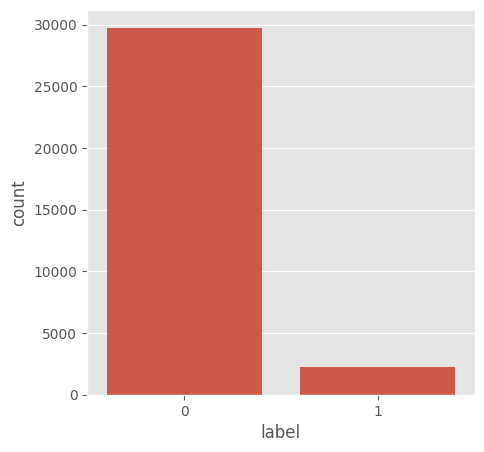

In [ ]:
# plot count of labels
fig = plt.figure(figsize=(5,5))
sns.countplot(x='label', data = tweet_df)

Text(0.5, 1.0, 'Distribution of sentiments')

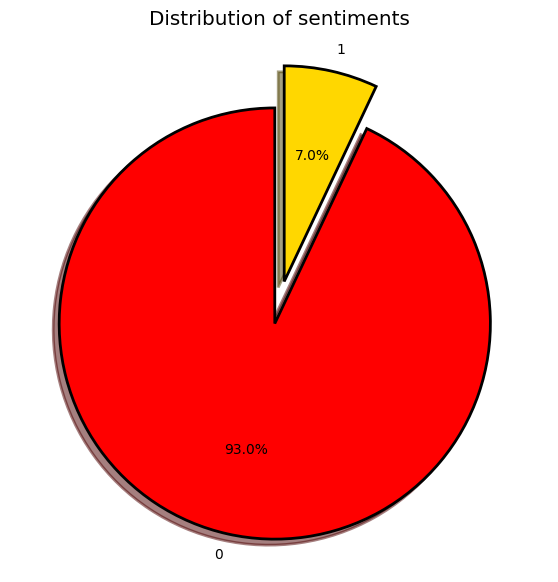

In [ ]:
# Distribution of sentiments with Pie chart
fig = plt.figure(figsize=(7,7))
colors = ("red", "gold")
wp = {'linewidth':2, 'edgecolor':"black"}
tags = tweet_df['label'].value_counts()
explode = (0.1, 0.1)
tags.plot(kind='pie',autopct = '%1.1f%%', shadow=True, colors = colors, startangle =90,
         wedgeprops = wp, explode = explode, label='')
plt.title('Distribution of sentiments')

In [ ]:
# we see some non hate tweets
non_hate_tweets = tweet_df[tweet_df.label == 0]
non_hate_tweets.head()

,id,label,tweet
0,1,0,user father dysfunctional selfish drag kid dys...
1,2,0,user user thanks lyft credit cant use cause do...
2,3,0,bihday majesty
3,4,0,model love u take u time ur
4,5,0,factsguide society motivation


In [ ]:
# we see some  hate tweets
non_hate_tweets = tweet_df[tweet_df.label == 1]
non_hate_tweets.head()

,id,label,tweet
13,14,1,user cnn call michigan middle school build wal...
14,15,1,comment australia opkillingbay seashepherd hel...
17,18,1,retweet agree
23,24,1,user user lumpy say prove lumpy
34,35,1,unbelievable 21st century wed need something l...


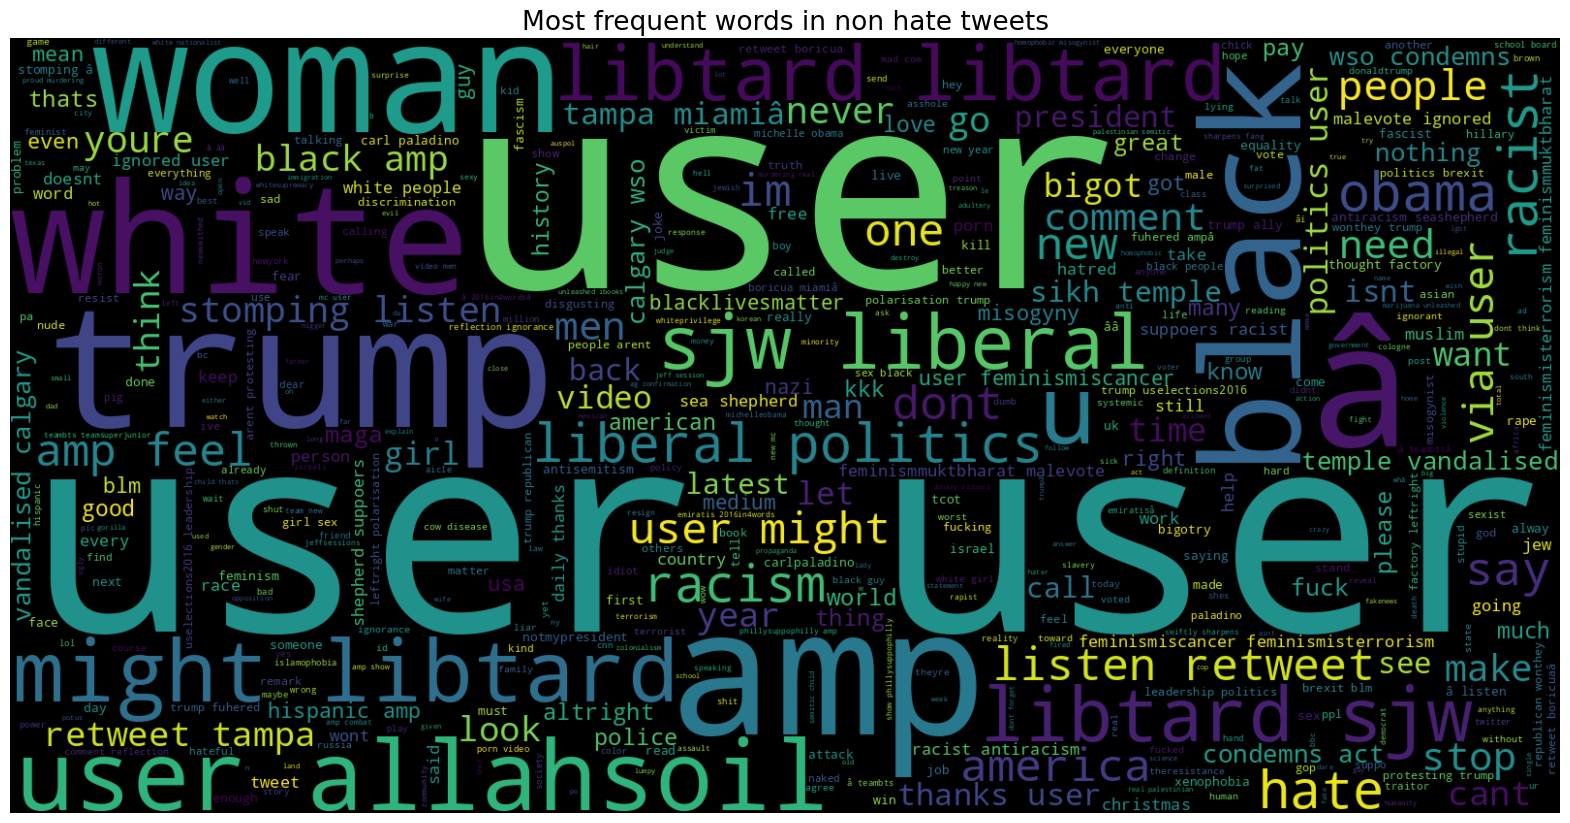

In [ ]:
# show non hate tweets wordcloud
text = ' '.join([word for word in non_hate_tweets['tweet']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in non hate tweets', fontsize = 19)
plt.show()

In [ ]:
# Create bi-gram language model
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with ngram_range=(1,2) and fit it on the 'tweet' column of tweet_df
vect = TfidfVectorizer(ngram_range=(1, 2)).fit(tweet_df['tweet'])

# Use get_feature_names_out() to retrieve the feature names
feature_names = vect.get_feature_names_out()

print("Number of features: {}\n".format(len(feature_names)))
print("First 20 features: \n{}".format(feature_names[:20]))


Number of features: 203050

First 20 features: 
['0000001' '0000001 polluting' '00027' '00027 photooftheday' '001' '0035'
 '00h30' '01' '01 4995' '01 7900' '01 blog' '01 croatia' '01 may'
 '01 shopalyssas' '0115' '0115 8599968' '0161' '0161 manny' '019'
 '019 previous']


In [ ]:
# Create Tr-gram language model
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with ngram_range=(1,3) and fit it on the 'tweet' column of tweet_df
vect = TfidfVectorizer(ngram_range=(1, 3)).fit(tweet_df['tweet'])

# Use get_feature_names_out() to retrieve the feature names
feature_names = vect.get_feature_names_out()

print("Number of features: {}\n".format(len(feature_names)))
print("First 20 features: \n{}".format(feature_names[:20]))


Number of features: 373785

First 20 features: 
['0000001' '0000001 polluting' '0000001 polluting niger' '00027'
 '00027 photooftheday' '00027 photooftheday music' '001' '0035' '00h30'
 '01' '01 4995' '01 4995 rustic' '01 7900' '01 7900 shopalyssas' '01 blog'
 '01 blog silver' '01 croatia' '01 croatia happy' '01 may' '01 may actual']


Model Building

In [ ]:
# seperate data in x and y and transform x data
X = tweet_df['tweet']
Y = tweet_df['label']
X = vect.transform(X)

In [ ]:
# Slite dta in train and test test data is 20%
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# Print size of x_train & x_test
print("Size of x_train:", (x_train.shape))
print("Size of y_train:", (y_train.shape))
print("Size of x_test: ", (x_test.shape))
print("Size of y_test: ", (y_test.shape))

Size of x_train: (25569, 373785)
Size of y_train: (25569,)
Size of x_test:  (6393, 373785)
Size of y_test:  (6393,)


In [ ]:
# Load and train data on logistic regression machine learning model's
# Calculate accuracy
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg_predict = logreg.predict(x_test)
logreg_acc = accuracy_score(logreg_predict, y_test)
print("Test accuarcy: {:.2f}%".format(logreg_acc*100))

Test accuarcy: 93.68%


In [ ]:
# Predict value from test data
print(confusion_matrix(y_test, logreg_predict))
print("\n")
print(classification_report(y_test, logreg_predict))

[[5937    0]
 [ 404   52]]


              precision    recall  f1-score   support

           0       0.94      1.00      0.97      5937
           1       1.00      0.11      0.20       456

    accuracy                           0.94      6393
   macro avg       0.97      0.56      0.59      6393
weighted avg       0.94      0.94      0.91      6393



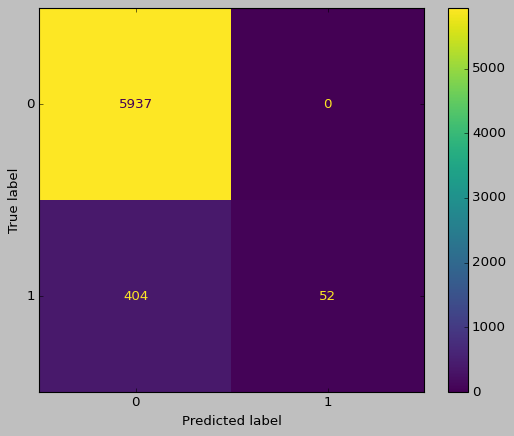

In [ ]:
# confusion_matrix visualize
style.use('classic')
cm = confusion_matrix(y_test, logreg_predict, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot()

In [ ]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [ ]:
param_grid = {'C':[100, 10, 1.0, 0.1, 0.01], 'solver' :['newton-cg', 'lbfgs','liblinear']}
grid = GridSearchCV(LogisticRegression(), param_grid, cv = 5)
grid.fit(x_train, y_train)
print("Best Cross validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)

Best Cross validation score: 0.96
Best parameters:  {'C': 100, 'solver': 'lbfgs'}


In [ ]:
y_pred = grid.predict(x_test)

In [ ]:
# after hyperparameters - tuning model accuracy
logreg_acc = accuracy_score(y_pred, y_test)
print("Test accuracy: {:.2f}%".format(logreg_acc*100))

Test accuracy: 95.82%


In [ ]:
print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[5932    5]
 [ 262  194]]


              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5937
           1       0.97      0.43      0.59       456

    accuracy                           0.96      6393
   macro avg       0.97      0.71      0.79      6393
weighted avg       0.96      0.96      0.95      6393

